# Double-Bottom — a quantitative teardown 🔬
### A mechanical two-trough detector · forward 5/10/20/40-day excess over base rate · one-sample + HAC *t* · a same-tape random-date placebo · a detector-strictness sweep · a magnitude-matched measured-move hit-rate test · a holding-period-matched long timer · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Target_hit_rate%3F: Busted](https://img.shields.io/badge/Target_hit_rate%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The double bottom is a *reversal* figure with a built-in price target, which makes it unusually testable — the job here is to (a) write down the closest mechanical definition of "two troughs at one level + a confirmed neckline break," (b) measure the post-breakout excess over each name's base rate, (c) confront both the target and a "hold to target-or-timeout" strategy with **matched** honest controls (magnitude for the target, holding period for the timer), and (d) run the synthetic positive control.

> ⚠️ **Subjectivity + survivorship note.** Chart figures are partly in the eye of the beholder; we test **one** mechanical definition and report a strictness sweep so the reader sees how the count and the (non-)edge move with it. Fixed **30-name large-cap basket + SPY** (the same basket as siblings 415 and 695), names still trading in 2026 — a *survivor* panel that tilts post-breakout forward returns mildly **up** (i.e. *for* the bullish read). Real data: yfinance daily auto-adjusted OHLC, 2005-01-03 → 2026-06-30, as-of **2026-06-30**. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `312be65a0274` / `cac3bd6bbfcc`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from double_bottom import data, strategy as st

ASOF = "2026-06-30"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real(asof=ASOF)
    CLOSES = PANEL["close"]
else:
    PANEL = CLOSES = None
print("real double-bottom cache present:", HAVE_REAL,
      "| names:", (0 if CLOSES is None else CLOSES.shape[1]),
      "| bars:", (0 if CLOSES is None else len(CLOSES)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-30', 'years': 21.5, 'n_bars': 5406, 'n_names': 30, 'fp_quantlab': '312be65a0274', 'fp_sha1': 'cac3bd6bbfcc', 'n_bottom': 560, 'spy_bottom': 12, 'bottom': [(5, 558, -0.073, 0.218, 52.0, -0.48, -0.49, 0.541, -0.173), (10, 558, -0.379, 0.2, 48.2, -1.91, -1.98, 0.643, -0.479), (20, 554, 0.019, 1.177, 51.6, 0.06, 0.06, 0.499, -0.081), (40, 550, -0.478, 1.814, 51.1, -1.12, -1.18, 0.594, -0.578)], 'robust': [(0.03, 0.07, 196, 0.846, 1.22, 0.374), (0.04, 0.05, 554, 0.019, 0.06, 0.501), (0.06, 0.03, 1304, -0.357, -2.01, 0.647)], 'spy': [(5, 12, 0.151, 0.385, 0.3, 0.427), (10, 12, 0.219, 0.686, 0.3, 0.417), (20, 12, 0.559, 1.495, 0.46, 0.354), (40, 12, 1.843, 3.71, 1.02, 0.14)], 'mm_n': 560, 'mm_hit': 452, 'mm_rate': 80.7, 'mm_lo': 77.2, 'mm_hi': 83.8, 'mm_placebo_n': 6000, 'mm_placebo_hit': 4782, 'mm_placebo_rate': 79.7, 'mm_z': 0.57, 'mm_median_days': 21, 'mm_rel_move': 5.92, 'tm_n': 545, 'tm_gross': 2.942, 'tm_net5': 2.842, 'tm_net10': 2.742, 'tm_t': 7.8, 'tm_hac': 8.87, 'tm_avg_hold': 49.8, 'tm_hit_share': 80.2, 'tm_excess': 0.125, 'tm_t_excess': 0.32, 'syn_null_mean': 1.57, 'syn_null_sd': 0.76, 'syn_null_fire': 0, 'syn_null_n': 20, 'syn': [(0.0, 160, 282, 282, 0.68, 2.12, 0.344, 57), (0.2, 160, 264, 264, 5.3, 10.32, 0.009, 72)], 'cost_bps': 5.0}


real double-bottom cache present: True | names: 30 | bars: 5406


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Double-bottom breakout excess never clears **t ≥ 2** in the pattern's favor: -0.48 / **-1.91** / +0.06 / -1.12 *t* for 5/10/20/40d (10d is the **wrong sign**). Random-date placebo *p* ∈ [0.50, 0.64] at every horizon. Measured-move hit rate 80.7% vs a magnitude-matched placebo 79.7% (*z* = 0.57). |
| **Tradability** | `MIRAGE` | Long-timer gross **+2.94%**/trade (*t* = 7.80 vs 0) collapses to **+0.12%** (HAC *t* = 0.32) vs a holding-period-matched base rate. |
| **Target hit rate beats a coin flip of the same size?** | `BUSTED` | 80.7% observed vs 79.7% magnitude-matched placebo, *z* = 0.57 — the target's "accuracy" is arithmetic on a rising market, not forecasting power. |

> 💡 In plain words: the shape is real and common; the breakout, the target and the patient hold-to-target strategy each look impressive by the naive read and each dissolve once measured against the fair, matched baseline.

## 1 · The claim, steelmanned

Let a **double bottom** be two swing lows $\{p_1,p_2\}$ at prices $h_1,h_2$ within tolerance $\tau$ of each other ($|h_2-h_1|/\max(h_1,h_2)\le\tau$), separated by an intervening swing high — the **neckline** $N$ — that rallies at least $\beta$ above the troughs' mean level $L=(h_1+h_2)/2$ (a genuine bounce, not a shelf). The **confirmed breakout** is the first close $c_b>N$ after $p_2$. Enter at $b+1$ (one lag); the trade's forward $H$-day return is $r_i(H)=c_{b+1+H}/c_{b+1}-1$. Define the **excess** over the name's base rate $\mu_k(H)$: $x_i(H)=r_i(H)-\mu_{k(i)}(H)$. The **measured-move target** is $T=N+(N-L)$, projected up from the neckline by the trough-to-neckline height.

- **H₁ (the breakout works).** Pooled $\bar{x}(H)>0$ and significant for some $H$.
- **H₂ (the target predicts a real move).** The target hit rate beats a random walk asked to travel the *same relative distance*.
- **H₃ (the strategy is deployable).** Holding to target-or-timeout beats a holding-period-matched base rate, net of costs.

We find **H₁ rejected** (max favorable $t=0.06$ < 2; the 10-day reading is *negative* at $t=-1.91$), **H₂ rejected** ($z=0.57$ vs the magnitude-matched placebo), **H₃ rejected** (excess $t=0.32$ vs the matched base rate). The shape is real and common; none of the three claims survive contact with a fair control.

## 2 · So what? — inference design

The Signal axis is a one-sample test of the pooled excess against zero, with an HAC (Newey-West) variant because breakouts cluster in time:

$$t=\frac{\bar{x}}{s_x/\sqrt{n}},\qquad t_{\text{HAC}}=\frac{\bar{x}}{\sqrt{\widehat{\sigma}^2_{\text{NW}}/n}}.$$

Three honesty problems sit on top of a naive read. **(a) The up-drift base rate:** any long signal inherits the market's positive drift, so we test **excess over each name's own base rate**, plus a **same-tape random-date placebo**. **(b) The target's own magnitude:** a nearby target gets hit often on pure noise, so the target hit-rate control must draw **the same relative distance** from a random entry, not an arbitrary one — see [`strategy.measured_move_hits`](../double_bottom/strategy.py). **(c) The variable holding period:** "hold to target-or-timeout" produces trades of different lengths, so the long-timer's honest bar is a **holding-period-matched** base rate — buy the same name, unconditionally, for the *same* number of days — not zero. Section 4c/4d make each trap visible.

## 3 · How we'd know — the protocol

- **Universe.** Fixed **30-name** large-cap basket incl. SPY (yfinance auto-adjusted daily OHLC, 2005-01-03→2026-06-30, as-of **2026-06-30**, **5,406** bars, fp `312be65a0274` / `cac3bd6bbfcc`). **Survivor** panel — named on the Signal axis.
- **Detector.** swing window $w=5$; two troughs within $\tau=0.04$ of each other; intervening rally $\beta\ge0.05$ above the trough level; figure span 15–150 bars; breakout = first close through the neckline within 30 bars (buffer 0); non-overlapping.
- **Timing.** signal known at the breakout close; **enter the next close** (one documented lag); hold $H\in\{5,10,20,40\}$ for the headline, or to target-or-timeout (126 trading days) for the long timer.
- **Metric.** pooled **excess over base rate** (headline); **hit rate vs a magnitude-matched placebo** (target); **excess vs a holding-period-matched base rate** (timer).
- **Null #1 (one-sample / HAC t)** vs 0, reported but *not* decisive by itself.
- **Null #2 (same-tape placebo).** random entry dates, same count per name, same base-rate subtraction.
- **Null #3 (magnitude-matched placebo).** random entries with a target of the *same relative size* as the observed average.
- **Robustness.** strictness sweep over $(\tau,\beta)$.
- **Costs.** 5 / 10 bps one-way × 2 (round trip) per event; long only, no borrow.
- **Positive control.** a synthetic panel with *planted* double bottoms + a forward-drift knob: edge 0 must NOT beat the placebo across 20 seeds even though a single-seed naive $t$ can read misleadingly high; a large edge must light up.

## 4 · The teardown

### 4a · The term structure of the (non-)edge

Pooled excess over base rate at each horizon, with the one-sample and HAC *t* annotated. A real reversal signal would be clearly positive; this never is.

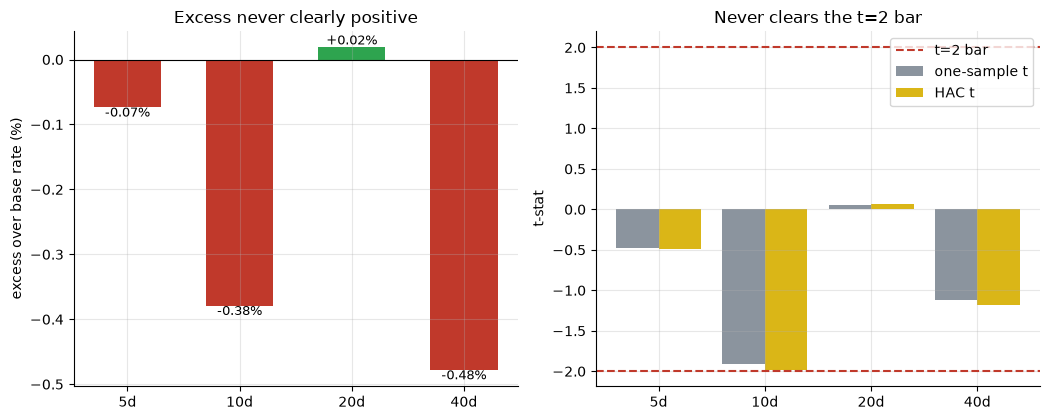

excess: [-0.073, -0.379, 0.019, -0.478]
t: [-0.48, -1.91, 0.06, -1.12] HAC: [-0.49, -1.98, 0.06, -1.18]


In [2]:
hs = [5, 10, 20, 40]
if HAVE_REAL:
    res = [st.run_experiment(PANEL, horizon=h, n_draws=2500) for h in hs]
    ex = [r['mean']*100 for r in res]; ts = [r['t'] for r in res]; hac = [r['hac_t'] for r in res]
else:
    ex = [b[2] for b in R['bottom']]; ts = [b[5] for b in R['bottom']]; hac = [b[6] for b in R['bottom']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
cols = [GREEN if v>0 else RED for v in ex]
a1.bar([f'{h}d' for h in hs], ex, color=cols, width=.6)
for i,v in enumerate(ex): a1.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('excess over base rate (%)'); a1.set_title('Excess never clearly positive')
a2.bar(np.arange(len(hs))-.2, ts, .4, color=GREY, label='one-sample t')
a2.bar(np.arange(len(hs))+.2, hac, .4, color=AMBER, label='HAC t')
a2.axhline(2, ls='--', c=RED, label='t=2 bar'); a2.axhline(-2, ls='--', c=RED)
a2.set_xticks(range(len(hs))); a2.set_xticklabels([f'{h}d' for h in hs]); a2.set_ylabel('t-stat'); a2.set_title('Never clears the t=2 bar'); a2.legend()
plt.tight_layout(); plt.show()
print('excess:', [round(v,3) for v in ex]); print('t:', [round(v,2) for v in ts], 'HAC:', [round(v,2) for v in hac])

> 💡 In plain words: the 10-day *t* is **-1.91** — the wrong sign for a reversal thesis — and no horizon reaches +2. The HAC version tells the same story.

### 4b · The decisive test — the same-tape random-date placebo

The honest null for a long signal on an up-drifting tape: random entry dates on the *same* names, same count, same base-rate subtraction.

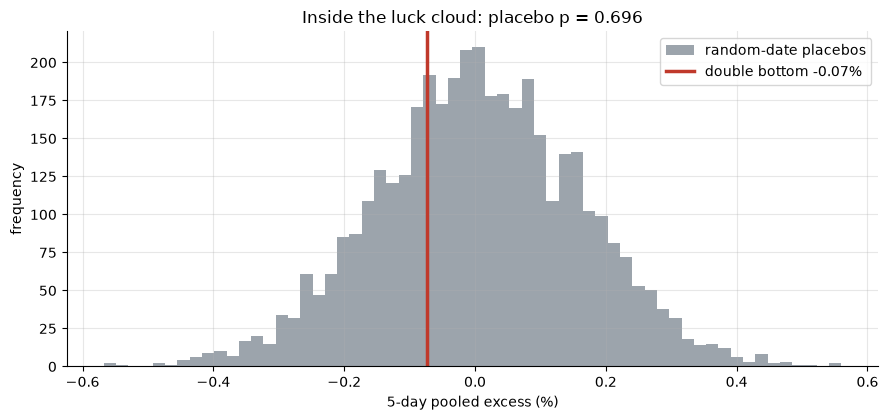

observed -0.07%  placebo p=0.696  (frozen p=0.541)


In [3]:
if HAVE_REAL:
    rng = np.random.default_rng(696); H = 5; lag = 1
    obs = st.run_experiment(PANEL, horizon=H, n_draws=1)['mean']*100
    draws = []
    bk = st.collect_breakouts(PANEL)
    for _ in range(4000):
        pool = []
        for tk, sigs in bk.items():
            c = CLOSES[tk].dropna().to_numpy(float); n=len(c); k=len(sigs)
            if k==0: continue
            hi = n - H - lag - 1
            if hi<=1: continue
            si = rng.integers(1, hi, size=k); entry=si+lag; exit_=entry+H
            br = st.base_rate(c, H)
            pool.extend((c[exit_]/c[entry]-1.0 - br).tolist())
        draws.append(np.mean(pool)*100)
    draws = np.array(draws); p = float((draws>=obs).mean())
else:
    obs = R['bottom'][0][2]; p = R['bottom'][0][7]
    rng = np.random.default_rng(696); draws = rng.normal(0.0, max(abs(obs),0.05)/0.5, 4000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=60, color=GREY, alpha=.85, label='random-date placebos')
ax.axvline(obs, color=RED, lw=2.5, label=f'double bottom {obs:+.2f}%')
ax.set_xlabel('5-day pooled excess (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Inside the luck cloud: placebo p = {p:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f}%  placebo p={p:.3f}  (frozen p={R["bottom"][0][7]})')

> 💡 In plain words: random entries beat the figure roughly **54%** of the time at 5 days. No horizon in [`docs/results.md`](../docs/results.md) beats its placebo by more than a coin flip's margin.

### 4c · The measured-move target — a magnitude-matched control, not a bare hit rate

A bare hit rate ($T$ touched within 6 months) means little on its own — a target a modest distance away gets hit often on pure noise. The honest control draws random entries on the same tapes and assigns them a target at the **same relative distance** as the observed average ($+5.9\%$), then asks whether *that* gets hit as often.

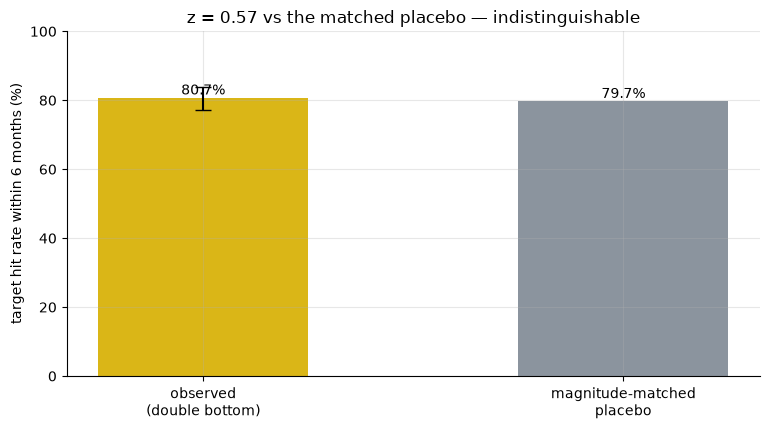

observed 80.7% [Wilson 77.2%,83.8%]  placebo 79.7%  z=0.57


In [4]:
if HAVE_REAL:
    mm = st.measured_move_hits(PANEL, max_days=126)
    hit, lo, hi = mm['hit_rate']*100, mm['hit_lo']*100, mm['hit_hi']*100
    plac, z = mm['placebo_rate']*100, mm['z_vs_placebo']
else:
    hit, lo, hi = R['mm_rate'], R['mm_lo'], R['mm_hi']; plac, z = R['mm_placebo_rate'], R['mm_z']
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.bar(['observed\n(double bottom)', 'magnitude-matched\nplacebo'], [hit, plac],
       color=[AMBER, GREY], width=.5)
ax.errorbar([0], [hit], yerr=[[hit-lo],[hi-hit]], fmt='none', ecolor='k', capsize=6)
for i,v in enumerate([hit, plac]): ax.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('target hit rate within 6 months (%)'); ax.set_ylim(0,100)
ax.set_title(f'z = {z:.2f} vs the matched placebo — indistinguishable')
plt.tight_layout(); plt.show()
print(f'observed {hit:.1f}% [Wilson {lo:.1f}%,{hi:.1f}%]  placebo {plac:.1f}%  z={z:.2f}')

> 💡 In plain words: **80.7%** observed vs **79.7%** magnitude-matched placebo, *z* = **0.57** — the Wilson interval on the observed rate ([77.2%, 83.8%]) comfortably contains the placebo rate. The "the pattern's own height tells you the target" folklore is arithmetic on a rising market wearing a chart-pattern's name.

### 4d · The long timer — the direction trap, on a variable holding period

Hold from entry to the day the measured-move target is touched, or 126 trading days (timeout), whichever comes first. The **excess** row races the trade against a **holding-period-matched** base rate — buy the same name, unconditionally, for the same number of days — the fair bar for a variable-length hold.

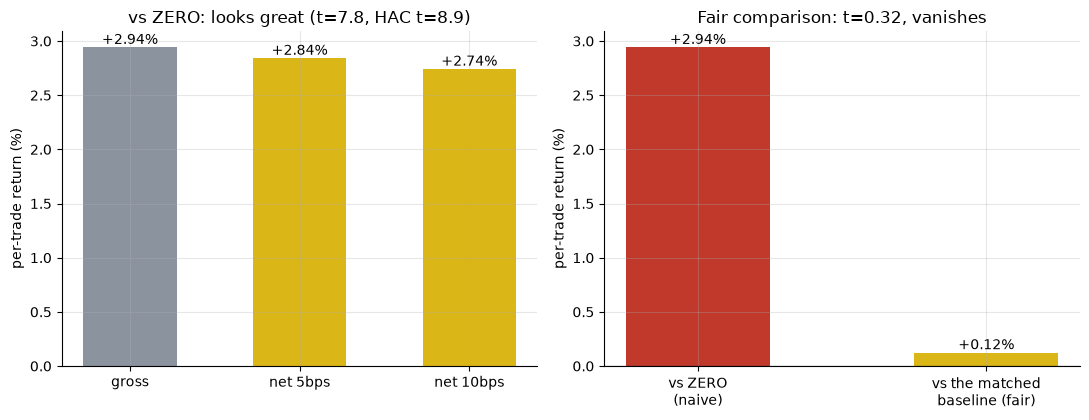

gross +2.94%  net5 +2.84%  net10 +2.74%  t(vs0)=7.80  HAC(vs0)=8.87
excess vs matched baseline: +0.125%  HAC t = 0.32


In [5]:
if HAVE_REAL:
    tp5 = st.timer_pnl(PANEL, max_days=126, cost_bps=5.0)
    tp10 = st.timer_pnl(PANEL, max_days=126, cost_bps=10.0)
    g, n5, n10 = tp5['gross']*100, tp5['net']*100, tp10['net']*100
    tv, hacv = tp5['t'], tp5['hac_t']
    ex, texv = tp5['excess']*100, tp5['t_excess']
else:
    g, n5, n10 = R['tm_gross'], R['tm_net5'], R['tm_net10']
    tv, hacv = R['tm_t'], R['tm_hac']; ex, texv = R['tm_excess'], R['tm_t_excess']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(['gross', 'net 5bps', 'net 10bps'], [g, n5, n10], color=[GREY, AMBER, AMBER], width=.55)
for i,v in enumerate([g, n5, n10]): a1.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
a1.set_ylabel('per-trade return (%)'); a1.set_title(f'vs ZERO: looks great (t={tv:.1f}, HAC t={hacv:.1f})')
a2.bar(['vs ZERO\n(naive)', 'vs the matched\nbaseline (fair)'], [g, ex], color=[RED, AMBER], width=.5)
for i,v in enumerate([g, ex]): a2.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('per-trade return (%)'); a2.set_title(f'Fair comparison: t={texv:.2f}, vanishes')
plt.tight_layout(); plt.show()
print(f'gross {g:+.2f}%  net5 {n5:+.2f}%  net10 {n10:+.2f}%  t(vs0)={tv:.2f}  HAC(vs0)={hacv:.2f}')
print(f'excess vs matched baseline: {ex:+.3f}%  HAC t = {texv:.2f}')

> 💡 In plain words: the left panel — **+2.94%**/trade, *t* = **7.8** vs zero — is exactly the trap the desk's methodology warns about: an average **50-day** hold on a rising basket looks "significant" against zero *by construction*. Raced against buying the same names for the same number of days, the excess is **+0.125%** at HAC *t* = **0.32** — statistically nothing. The target-hit share (80% of trades exit on a target touch rather than timeout) is consistent with 4c: the target is easy to hit on drift alone.

### 4e · Robustness — the (non-)edge is a tolerance artefact

Sweep the detector strictness $(\tau,\beta)$ at the 20-day horizon. If the figure were real, a stricter "cleaner" pattern should be *better*. Instead the (non-)edge wanders and only ever brushes past 2 on the **wrong side**.

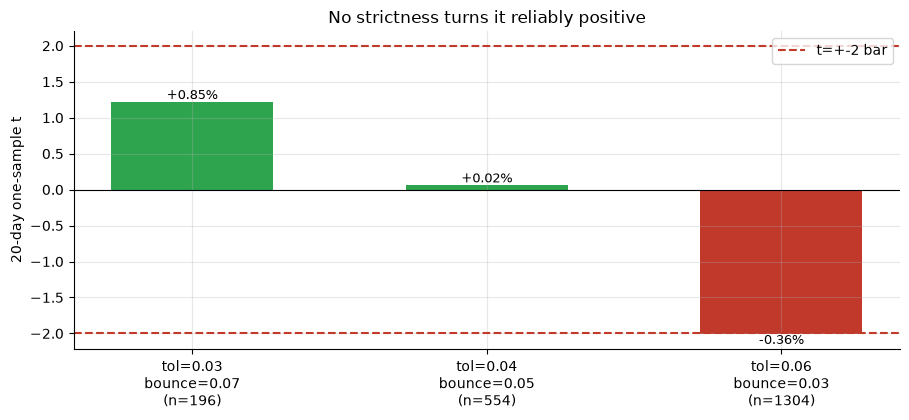

robustness (tol, bounce, n, excess%, t, p): [(0.03, 0.07, 196, 0.85, 1.22, 0.374), (0.04, 0.05, 554, 0.02, 0.06, 0.501), (0.06, 0.03, 1304, -0.36, -2.01, 0.647)]


In [6]:
settings = [(0.03,0.07),(0.04,0.05),(0.06,0.03)]
if HAVE_REAL:
    rob = [st.run_experiment(PANEL, horizon=20, n_draws=3000, tolerance=t_, min_bounce=mb) for t_,mb in settings]
    rob = [(s[0], s[1], r['n_events'], r['mean']*100, r['t'], r['p_placebo']) for s,r in zip(settings,rob)]
else:
    rob = R['robust']
fig, ax = plt.subplots(figsize=(9.2, 4.3))
labels = [f'tol={r[0]}\nbounce={r[1]}\n(n={r[2]})' for r in rob]
ts = [r[4] for r in rob]
cols = [GREEN if t_>0 else RED for t_ in ts]
ax.bar(labels, ts, color=cols, width=.55)
ax.axhline(2, ls='--', c=RED, label='t=+-2 bar'); ax.axhline(-2, ls='--', c=RED); ax.axhline(0,c='k',lw=.8)
for i,r in enumerate(rob): ax.annotate(f'{r[3]:+.2f}%',(i,r[4]),ha='center',va='bottom' if r[4]>=0 else 'top',fontsize=9)
ax.set_ylabel('20-day one-sample t'); ax.set_title('No strictness turns it reliably positive')
ax.legend(); plt.tight_layout(); plt.show()
print('robustness (tol, bounce, n, excess%, t, p):', [(r[0],r[1],r[2],round(r[3],2),round(r[4],2),round(r[5],3)) for r in rob])

> 💡 In plain words: the strictest setting (n=196) reads **+0.85%** at t=1.22 — positive but well under 2; the loosest (n=1304) is **-0.36%** at t=-2.01 — the *only* setting to cross $|t|=2$, and on the wrong side. A real figure gets cleaner when you demand a cleaner shape; this doesn't.

### 4f · SPY-only — the README hook

The index itself, isolated. Too few events to say anything on its own, but consistent with the pooled basket result.

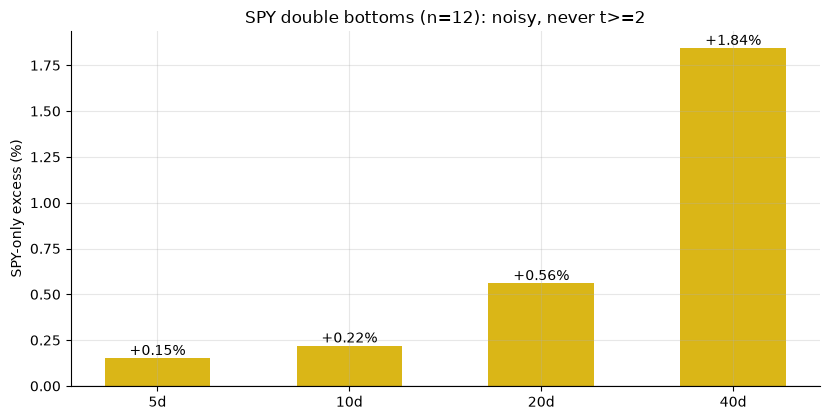

SPY excess: [0.151, 0.219, 0.559, 1.843]  t: [0.3, 0.3, 0.46, 1.02]


In [7]:
if HAVE_REAL:
    spyres = [st.run_experiment(PANEL, horizon=h, names=['SPY'], n_draws=3000) for h in hs]
    spy_ex = [r['mean']*100 for r in spyres]; spy_t = [r['t'] for r in spyres]
else:
    spy_ex = [s[2] for s in R['spy']]; spy_t = [s[4] for s in R['spy']]
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.bar([f'{h}d' for h in hs], spy_ex, color=AMBER, width=.55)
for i,v in enumerate(spy_ex): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('SPY-only excess (%)'); ax.set_title(f'SPY double bottoms (n={R["spy_bottom"]}): noisy, never t>=2')
plt.tight_layout(); plt.show()
print('SPY excess:', [round(v,3) for v in spy_ex], ' t:', [round(v,2) for v in spy_t])

> 💡 In plain words: only **12** confirmed double bottoms on SPY in 21.5 years — a small sample — and every *t* stays under 1.1. "Buy the SPY double bottom" is a non-event, not a headline strategy.

### 4g · Faithful-engine & power control — the harness can catch a real edge

On a synthetic panel with *planted* double bottoms: with **zero** post-breakout drift the same-tape placebo must NOT light up (note the naive *t* averages **+1.57** across seeds — mildly positive from the figure's own geometry, exactly why the placebo, not the raw *t*, is the arbiter); with a **large** planted drift it must light up hard.

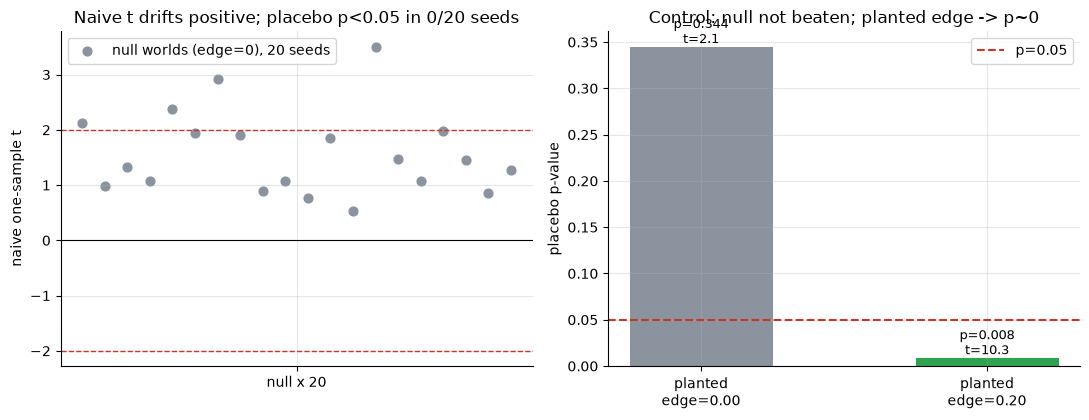

null naive t: mean=+1.57 sd=0.76  p<0.05 in 0/20
planted +0.00: planted=160 detected=282 excess=+0.68% t=+2.12 p_placebo=0.344 win=57%
planted +0.20: planted=160 detected=264 excess=+5.30% t=+10.32 p_placebo=0.008 win=72%


In [8]:
null_ts, null_ps = [], []
for s_ in range(20):
    px, _ = data.synthetic_panel(edge=0.0, seed=696 + s_, n_planted=8, daily_vol=0.011)
    r = st.run_experiment(px, horizon=20, n_draws=800, seed=696 + s_)
    null_ts.append(r['t']); null_ps.append(r['p_placebo'])
null_ts = np.asarray(null_ts); null_ps = np.asarray(null_ps)
rows = []
for edge in (0.0, 0.20):
    px, truth = data.synthetic_panel(edge=edge, seed=696, n_planted=8, daily_vol=0.011)
    r = st.run_experiment(px, horizon=20, n_draws=2000)
    rows.append((edge, truth['n_planted_total'], r['n_breakouts'], r['mean']*100, r['t'], r['p_placebo'], r['win']*100))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.scatter(np.zeros(20) + np.linspace(-.1,.1,20), null_ts, color=GREY, s=40, label='null worlds (edge=0), 20 seeds')
a1.axhline(-2, ls='--', c=RED, lw=1); a1.axhline(2, ls='--', c=RED, lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_xticks([0]); a1.set_xticklabels(['null x 20']); a1.set_ylabel('naive one-sample t')
a1.set_title(f'Naive t drifts positive; placebo p<0.05 in {int((null_ps<0.05).sum())}/20 seeds'); a1.legend()
labels = [f'planted\nedge={e:.2f}' for e,_,_,_,_,_,_ in rows]
ps = [r[5] for r in rows]
a2.bar(labels, ps, color=[GREY, GREEN], width=.5)
a2.axhline(0.05, ls='--', c=RED, label='p=0.05')
for i,r in enumerate(rows): a2.annotate(f'p={r[5]:.3f}\nt={r[4]:.1f}',(i,r[5]),ha='center',va='bottom',fontsize=9)
a2.set_ylabel('placebo p-value'); a2.set_title('Control: null not beaten; planted edge -> p~0'); a2.legend()
plt.tight_layout(); plt.show()
print(f'null naive t: mean={null_ts.mean():+.2f} sd={null_ts.std(ddof=1):.2f}  p<0.05 in {(null_ps<0.05).sum()}/20')
for e,pl,de,ex,t,p,w in rows: print(f'planted {e:+.2f}: planted={pl} detected={de} excess={ex:+.2f}% t={t:+.2f} p_placebo={p:.3f} win={w:.0f}%')

> 💡 In plain words: with **no** planted edge the naive *t* averages **+1.57** (sd 0.76) across 20 seeds — mildly positive from the pattern's own geometry — but the **placebo never fires at the 5% level** (0/20 seeds). A planted drift of +20% reaches placebo *p* = **0.009** at *t* = **10.3**, win **72%** — the harness *would* catch a real double-bottom edge if one existed. This is exactly why the placebo — not the raw *t* — is the arbiter throughout this study.

## 5 · The verdict

- **Signal `NONE`** — the double-bottom breakout excess never clears **t ≥ 2** in the pattern's favor at any horizon (-0.48 / **-1.91** / +0.06 / -1.12 for 5/10/20/40d — 10d is the *wrong sign*). The random-date placebo is never beaten (*p* ∈ [0.50, 0.64]). The measured-move target hits 80.7% of the time — statistically identical to a magnitude-matched placebo's 79.7% (*z* = 0.57). No tolerance in the robustness sweep turns the edge reliably positive. Carries a **survivorship** caveat that tilts *toward* finding a working reversal signal. NONE, not WEAK.
- **Tradability `MIRAGE`** — the long-timer gross P&L (**+2.94%**/trade, *t* = 7.80 vs zero) collapses to **+0.125%** (HAC *t* = 0.32) once raced against a holding-period-matched base rate — the classic direction trap, demonstrated live. Costs only push the already-flat headline horizons further negative.
- **Target hit rate beats a coin flip of the same size? `BUSTED`** — 80.7% observed vs 79.7% magnitude-matched placebo (*z* = 0.57). The measured-move target's celebrated "accuracy" is a function of the target being an achievable distance on a rising basket, not of the W-shape forecasting anything.

## 6 · Going further

- **The general lesson.** Any variable-length "hold to target" strategy on a rising universe must be raced against a **holding-period-matched** baseline, not zero — the trap shown live in 4d applies equally to any target-and-stop system, not just chart patterns. Likewise, any "hit rate" claim for a price target needs a **magnitude-matched** control (4c), or it just measures how close the target was.
- **The "tested a level twice" neighbours.** [189-double-top](../../189-double-top/) runs a fixed-horizon-vs-random-placebo protocol on both the bearish and bullish versions; [415-triple-top-bottom](../../415-triple-top-bottom/) is the three-tap version; [695-inverse-head-shoulders](../../695-inverse-head-shoulders/) is the three-trough, asymmetric-head version; [694-matching-low](../../694-matching-low/) is the two-*candle* micro version. None of them run this study's measured-move + long-timer bar on the two-trough figure.

*The reproducible core is offline and deterministic; the detector is two swing lows within a stated tolerance, a genuine intervening rally, and a confirmed neckline break, with a strictness sweep, a magnitude-matched measured-move test and a holding-period-matched long timer. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*